In [5]:
import os
path = r'C:\Users\yeseo\Downloads\ODR20260914210047380'
print(os.path.isdir(path))   # True면 폴더, False면 파일
print(os.path.isfile(path))  # True면 파일

True
False


In [6]:
import os
path = r'C:\Users\yeseo\Downloads\ODR20260914210047380'
print(os.listdir(path))

['ABP_CONTEST_DATA.csv']


In [7]:
import pandas as pd

df = pd.read_csv(r'C:\Users\yeseo\Downloads\ODR20260914210047380\ABP_CONTEST_DATA.csv')

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (242574, 9)


,STRD_YYMM,SIDO_NM,CCG_NM,GENDER_CD,AGE_CD,TP_BUZ_NO,TP_BUZ_NM,amt,cnt
0,202605,서울특별시,용산구,2,3,8006,서양음식,734430000,38874
1,202605,부산광역시,사상구,2,4,8001,일반한식,424220000,10929
2,202601,경상북도,포항시 북구,1,5,4010,편 의 점,283030000,29848
3,202601,전라남도,여수시,1,6,4010,편 의 점,204060000,20727
4,202606,서울특별시,송파구,1,3,4010,편 의 점,575120000,86780


In [8]:
# 데이터 앞부분
display(df.head())

# 컬럼명
print("\n컬럼명:")
print(df.columns.tolist())

# 데이터 타입
print("\n데이터 타입:")
print(df.dtypes)

# 결측치
print("\n결측치:")
print(df.isnull().sum())

# 중복 행
print("\n중복 행:", df.duplicated().sum())

,STRD_YYMM,SIDO_NM,CCG_NM,GENDER_CD,AGE_CD,TP_BUZ_NO,TP_BUZ_NM,amt,cnt
0,202605,서울특별시,용산구,2,3,8006,서양음식,734430000,38874
1,202605,부산광역시,사상구,2,4,8001,일반한식,424220000,10929
2,202601,경상북도,포항시 북구,1,5,4010,편 의 점,283030000,29848
3,202601,전라남도,여수시,1,6,4010,편 의 점,204060000,20727
4,202606,서울특별시,송파구,1,3,4010,편 의 점,575120000,86780



컬럼명:
['STRD_YYMM', 'SIDO_NM', 'CCG_NM', 'GENDER_CD', 'AGE_CD', 'TP_BUZ_NO', 'TP_BUZ_NM', 'amt', 'cnt']

데이터 타입:
STRD_YYMM     int64
SIDO_NM      object
CCG_NM       object
GENDER_CD    object
AGE_CD       object
TP_BUZ_NO     int64
TP_BUZ_NM    object
amt           int64
cnt           int64
dtype: object

결측치:
STRD_YYMM    0
SIDO_NM      0
CCG_NM       0
GENDER_CD    0
AGE_CD       0
TP_BUZ_NO    0
TP_BUZ_NM    0
amt          0
cnt          0
dtype: int64

중복 행: 0


In [13]:
# 2. 데이터의 주요 변수 확인
# 기간, 지역, 성별, 연령대, 업종 등 각 변수의 범주와 개수를 확인한다.

# 분석 기간
print("분석 기간:")
print(sorted(df['STRD_YYMM'].unique()))

# 시·도
print("\n시·도 수:", df['SIDO_NM'].nunique())
print(df['SIDO_NM'].unique())

# 시·군·구
print("\n시·군·구 수:", df['CCG_NM'].nunique())

# 성별
print("\n성별:")
print(df['GENDER_CD'].value_counts())

# 연령대
print("\n연령대:")
print(df['AGE_CD'].value_counts())

# 업종
print("\n업종 수:", df['TP_BUZ_NM'].nunique())
print(df['TP_BUZ_NM'].value_counts())

분석 기간:
[202601, 202602, 202603, 202604, 202605, 202606]

시·도 수: 17
['서울특별시' '부산광역시' '경상북도' '전라남도' '전북특별자치도' '경기도' '경상남도' '대구광역시' '인천광역시'
 '충청남도' '강원특별자치도' '울산광역시' '대전광역시' '제주특별자치도' '광주광역시' '충청북도' '세종특별자치시']

시·군·구 수: 233

성별:
GENDER_CD
1    80554
2    78681
3    70178
x    13161
Name: count, dtype: int64

연령대:
AGE_CD
6    40326
5    40264
4    39762
3    39335
2    38433
1    31293
x    13161
Name: count, dtype: int64

업종 수: 11
TP_BUZ_NM
편 의 점    28967
서양음식     28627
슈퍼 마켓    28456
일반한식     28406
스넥       27438
제 과 점    27224
중국음식     26805
일식회집     21714
대형할인점    21529
갈비전문점     2860
한정식        548
Name: count, dtype: int64


월별 이용금액:


STRD_YYMM
202601    2819035480000
202602    2668138270000
202603    2858668760000
202604    2827034240000
202605    3209981290000
202606    2842042030000
Name: amt, dtype: int64


월별 이용건수:


STRD_YYMM
202601    148307836
202602    138483094
202603    159859550
202604    162268230
202605    175318857
202606    164867501
Name: cnt, dtype: int64

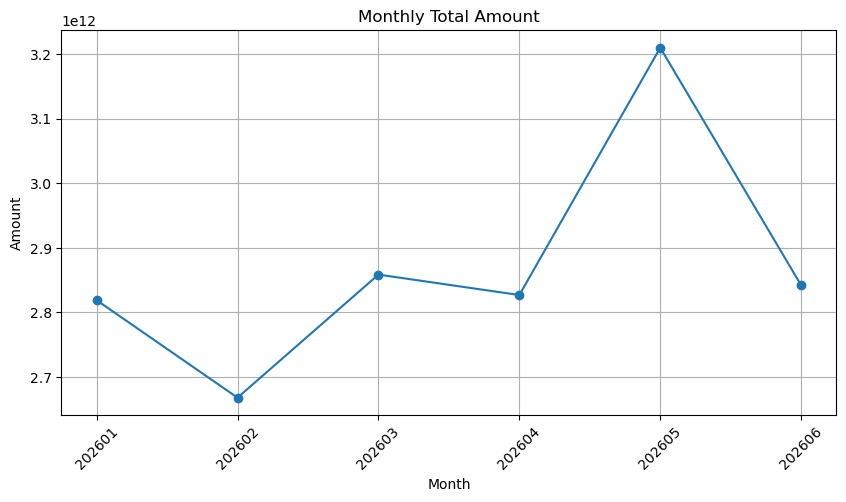

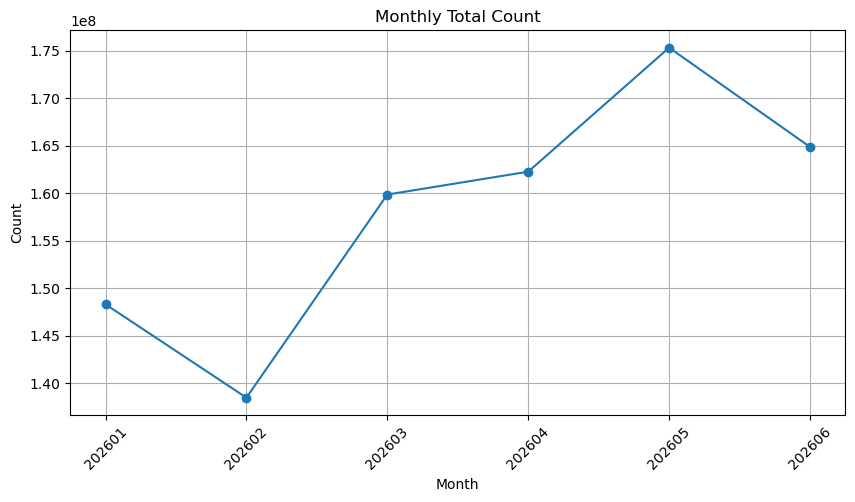

In [14]:
# 3. 월별 전체 소비 흐름 분석
# 2026년 1월부터 6월까지 전체 이용금액과 이용건수가
# 월별로 어떻게 변화했는지 확인한다.

# 월별 이용금액
monthly_amt = df.groupby('STRD_YYMM')['amt'].sum()

# 월별 이용건수
monthly_cnt = df.groupby('STRD_YYMM')['cnt'].sum()

print("월별 이용금액:")
display(monthly_amt)

print("\n월별 이용건수:")
display(monthly_cnt)


# 월별 이용금액 그래프
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_amt.index.astype(str),
    monthly_amt.values,
    marker='o'
)

plt.title('Monthly Total Amount')
plt.xlabel('Month')
plt.ylabel('Amount')

plt.xticks(rotation=45)
plt.grid()
plt.show()


# 월별 이용건수 그래프
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_cnt.index.astype(str),
    monthly_cnt.values,
    marker='o'
)

plt.title('Monthly Total Count')
plt.xlabel('Month')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.grid()
plt.show()

업종별 이용금액:


TP_BUZ_NM
일반한식     6348450610000
슈퍼 마켓    2723898860000
편 의 점    2483898980000
서양음식     1916074350000
대형할인점    1654789730000
스넥        571506890000
중국음식      529612890000
제 과 점     498417820000
일식회집      487750290000
갈비전문점       9269650000
한정식         1230000000
Name: amt, dtype: int64

업종별 이용건수:


TP_BUZ_NM
편 의 점    306005921
서양음식     174739374
일반한식     173301016
슈퍼 마켓    143282938
대형할인점     47906339
제 과 점     39671152
스넥        35722693
중국음식      18567799
일식회집       9769473
갈비전문점       122645
한정식          15718
Name: cnt, dtype: int64

업종별 월별 이용금액:


,STRD_YYMM,TP_BUZ_NM,amt
0,202601,갈비전문점,1512040000
1,202601,대형할인점,299391180000
2,202601,서양음식,305548260000
3,202601,슈퍼 마켓,452670390000
4,202601,스넥,88406910000
...,...,...,...
61,202606,일식회집,78574190000
62,202606,제 과 점,76943510000
63,202606,중국음식,83308640000
64,202606,편 의 점,441049210000


업종별 월별 이용금액:


STRD_YYMM,202601,202602,202603,202604,202605,202606
TP_BUZ_NM,,,,,,
갈비전문점,1512040000,1269240000,1410390000,1469400000,2052170000,1556410000
대형할인점,299391180000,284664730000,280588580000,265164800000,283389190000,241591250000
서양음식,305548260000,295173500000,315705370000,317579180000,357812980000,324255060000
슈퍼 마켓,452670390000,452164340000,441083560000,431889260000,492054850000,454036460000
스넥,88406910000,81783280000,93324900000,97009860000,111378790000,99603150000
일반한식,1034372600000,947861530000,1050506130000,1050731260000,1224076560000,1040902530000
일식회집,81959700000,74668600000,80309810000,80374580000,91863410000,78574190000
제 과 점,79306430000,81587900000,86333690000,83391360000,90854930000,76943510000
중국음식,89538670000,84363470000,90129500000,84752370000,97520240000,83308640000


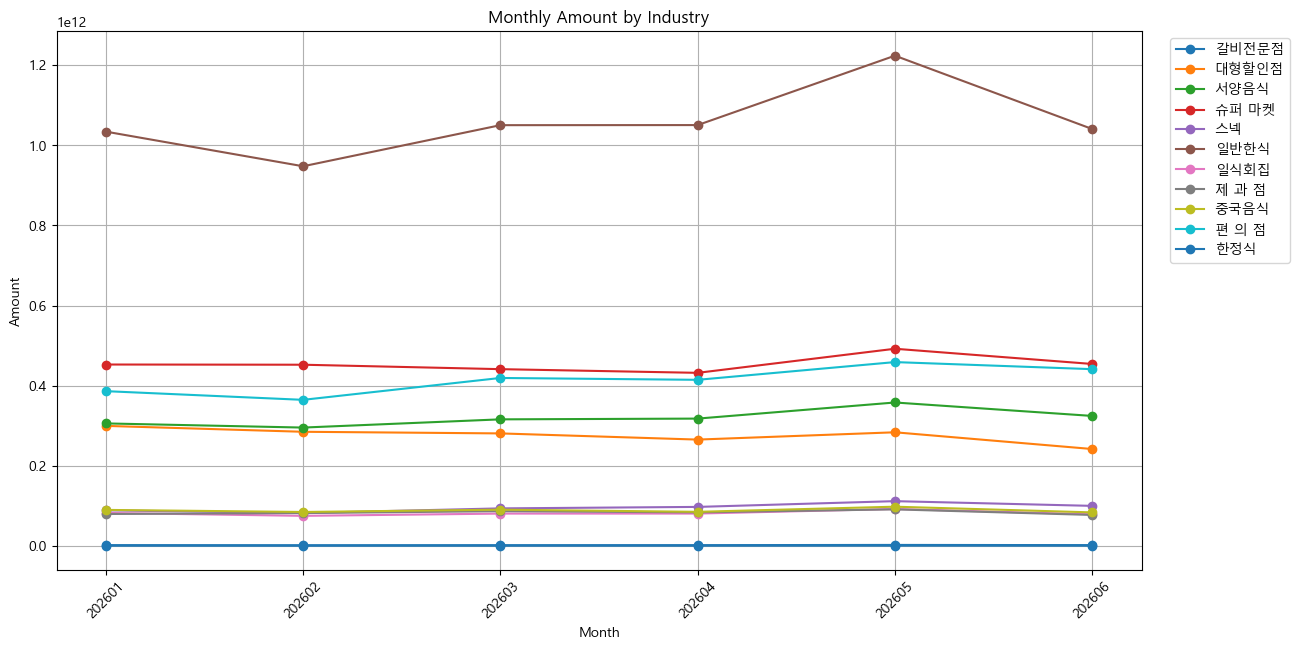

In [17]:
# 4. 업종별 소비 분석
# 전체 기간 동안 업종별 이용금액과 이용건수를 비교하고,
# 업종별 소비가 월별로 어떻게 변화했는지 확인한다.


# 4-1. 업종별 전체 이용금액
# 전체 기간 동안 어떤 업종의 소비금액이 큰지 확인한다.

industry_amt = (
    df.groupby('TP_BUZ_NM')['amt']
    .sum()
    .sort_values(ascending=False)
)

print("업종별 이용금액:")
display(industry_amt)


# 4-2. 업종별 전체 이용건수
# 전체 기간 동안 업종별 카드 이용건수를 비교한다.

industry_cnt = (
    df.groupby('TP_BUZ_NM')['cnt']
    .sum()
    .sort_values(ascending=False)
)

print("업종별 이용건수:")
display(industry_cnt)


# 4-3. 업종별 월별 이용금액
# 각 업종의 소비금액이 월별로 어떻게 변화했는지 확인한다.

industry_monthly = (
    df.groupby(['STRD_YYMM', 'TP_BUZ_NM'])['amt']
    .sum()
    .reset_index()
)

print("업종별 월별 이용금액:")
display(industry_monthly)


# 4-4. 업종별 월별 이용금액 비교
# 업종을 행, 월을 열로 배치하여 업종별 월별 소비금액을 비교한다.

industry_pivot = industry_monthly.pivot(
    index='STRD_YYMM',
    columns='TP_BUZ_NM',
    values='amt'
)

print("업종별 월별 이용금액:")
display(industry_pivot.T)


# 4-5. 업종별 월별 소비금액 추이
# 각 업종의 소비금액이 1월부터 6월까지
# 어떤 흐름으로 변화했는지 그래프로 확인한다.

plt.figure(figsize=(14, 7))

for industry in industry_pivot.columns:
    plt.plot(
        industry_pivot.index.astype(str),
        industry_pivot[industry],
        marker='o',
        label=industry
    )

plt.title('Monthly Amount by Industry')
plt.xlabel('Month')
plt.ylabel('Amount')

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid()
plt.show()

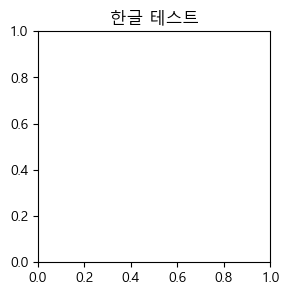

In [16]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 테스트
plt.figure(figsize=(3,3))
plt.title('한글 테스트')
plt.show()

In [20]:
# 5-1. 연령대별 업종 이용금액
# 각 연령대가 어떤 업종에서 소비금액을 많이 사용하는지 확인한다.

age_industry_amt = (
    df.groupby(['AGE_CD', 'TP_BUZ_NM'])['amt']
    .sum()
    .reset_index()
)

# 연령대를 행, 업종을 열로 변환
age_industry_pivot = age_industry_amt.pivot(
    index='AGE_CD',
    columns='TP_BUZ_NM',
    values='amt'
)

display(age_industry_pivot)

TP_BUZ_NM,갈비전문점,대형할인점,서양음식,슈퍼 마켓,스넥,일반한식,일식회집,제 과 점,중국음식,편 의 점,한정식
AGE_CD,,,,,,,,,,,
1,NaN,5.329290e+09,3.292944e+10,9.778660e+09,7.961190e+09,4.000609e+10,5.478250e+09,4.152330e+09,7.039290e+09,5.190021e+10,NaN
2,2.048900e+08,7.893939e+10,2.924478e+11,1.270682e+11,5.551874e+10,4.852356e+11,7.138165e+10,4.163591e+10,5.863250e+10,3.434798e+11,29140000.0
3,7.707600e+08,2.303887e+11,3.893335e+11,2.858703e+11,8.302064e+10,8.435280e+11,9.340616e+10,7.271296e+10,8.779096e+10,4.765873e+11,113530000.0
4,1.410130e+09,3.641396e+11,4.005624e+11,4.884113e+11,1.301274e+11,1.210180e+12,9.602236e+10,9.896582e+10,1.180230e+11,5.786133e+11,145830000.0
5,2.468050e+09,4.145532e+11,3.719542e+11,7.011936e+11,1.431713e+11,1.602320e+12,9.943364e+10,1.079004e+11,1.195925e+11,5.514589e+11,340950000.0
6,3.853220e+09,5.111309e+11,2.787869e+11,9.531508e+11,1.108673e+11,1.766574e+12,9.177498e+10,1.152789e+11,1.050499e+11,3.479885e+11,568330000.0
x,5.626000e+08,5.030873e+10,1.500602e+11,1.584259e+11,4.084027e+10,4.006066e+11,3.025325e+10,5.777144e+10,3.348479e+10,1.338710e+11,32220000.0


In [21]:
# 5-2. 연령대별 업종 소비 비중
# 각 연령대의 전체 소비금액을 100%로 보고,
# 업종별 소비가 차지하는 비중을 계산한다.

age_industry_share = age_industry_pivot.div(
    age_industry_pivot.sum(axis=1),
    axis=0
) * 100

display(age_industry_share.round(2))

TP_BUZ_NM,갈비전문점,대형할인점,서양음식,슈퍼 마켓,스넥,일반한식,일식회집,제 과 점,중국음식,편 의 점,한정식
AGE_CD,,,,,,,,,,,
1,NaN,3.24,20.01,5.94,4.84,24.31,3.33,2.52,4.28,31.54,NaN
2,0.01,5.08,18.81,8.17,3.57,31.21,4.59,2.68,3.77,22.09,0.00
3,0.03,8.99,15.19,11.15,3.24,32.91,3.64,2.84,3.42,18.59,0.00
4,0.04,10.44,11.49,14.01,3.73,34.71,2.75,2.84,3.39,16.60,0.00
5,0.06,10.08,9.04,17.04,3.48,38.94,2.42,2.62,2.91,13.40,0.01
6,0.09,11.93,6.51,22.24,2.59,41.23,2.14,2.69,2.45,8.12,0.01
x,0.05,4.76,14.21,15.00,3.87,37.93,2.86,5.47,3.17,12.67,0.00


In [22]:
# 5-3. 연령대별 1월 → 6월 소비 변화
# 각 연령대의 소비금액이 2026년 1월에서 6월 사이
# 얼마나 증가하거나 감소했는지 확인한다.

# 연령대별 월별 이용금액 계산
age_monthly_amt = (
    df.groupby(['STRD_YYMM', 'AGE_CD'])['amt']
    .sum()
    .reset_index()
)

# 월을 행, 연령대를 열로 변환
age_monthly_pivot = age_monthly_amt.pivot(
    index='STRD_YYMM',
    columns='AGE_CD',
    values='amt'
)

print("연령대별 월별 이용금액:")
display(age_monthly_pivot)

연령대별 월별 이용금액:


AGE_CD,1,2,3,4,5,6,x
STRD_YYMM,,,,,,,
202601,26267630000,259726600000,433125430000,597309180000,696425090000,692478400000,113703150000
202602,24682300000,241507160000,401882660000,554471550000,648758450000,652085610000,144750540000
202603,29601890000,267561630000,428997450000,577551810000,682574730000,713526350000,158854900000
202604,28188000000,255059100000,423477330000,569616720000,680130940000,720797440000,149764710000
202605,29924320000,280858690000,466650660000,634997410000,739926670000,778026750000,279596790000
202606,25910610000,249860440000,409389310000,552654000000,666571320000,728109530000,209546820000


In [23]:
# 1월 대비 6월 소비금액 변화율 계산
age_change = (
    (age_monthly_pivot.loc[202606] - age_monthly_pivot.loc[202601])
    / age_monthly_pivot.loc[202601]
    * 100
)

age_change = age_change.sort_values()

print("연령대별 1월 → 6월 소비금액 변화율:")
display(age_change.round(2))

연령대별 1월 → 6월 소비금액 변화율:


AGE_CD
4    -7.48
3    -5.48
5    -4.29
2    -3.80
1    -1.36
6     5.15
x    84.29
dtype: float64

In [26]:
# 연령대 x 업종별 월별 이용금액
age_industry_monthly = (
    df.groupby(['STRD_YYMM', 'AGE_CD', 'TP_BUZ_NM'])['amt']
    .sum()
    .reset_index()
)

# 1월, 6월만 비교
jan = age_industry_monthly[age_industry_monthly['STRD_YYMM'] == 202601]
jun = age_industry_monthly[age_industry_monthly['STRD_YYMM'] == 202606]

# 연령대+업종 기준으로 병합
compare = pd.merge(
    jan[['AGE_CD', 'TP_BUZ_NM', 'amt']],
    jun[['AGE_CD', 'TP_BUZ_NM', 'amt']],
    on=['AGE_CD', 'TP_BUZ_NM'],
    suffixes=('_jan', '_jun')
)

# 변화율 계산
compare['change_rate(%)'] = (
    (compare['amt_jun'] - compare['amt_jan']) / compare['amt_jan'] * 100
).round(2)

# 연령대별로 어느 업종이 가장 많이 늘고 줄었는지 정렬해서 확인
compare_sorted = compare.sort_values(['AGE_CD', 'change_rate(%)'], ascending=[True, False])
display(compare_sorted)

,AGE_CD,TP_BUZ_NM,amt_jan,amt_jun,change_rate(%)
8,1,편 의 점,7271740000,9169830000,26.10
1,1,서양음식,5024930000,5190960000,3.30
7,1,중국음식,1093420000,1084070000,-0.86
3,1,스넥,1244300000,1215780000,-2.29
2,1,슈퍼 마켓,1657550000,1599930000,-3.48
...,...,...,...,...,...
66,x,서양음식,17759460000,33567100000,89.01
69,x,일반한식,42917360000,73423350000,71.08
72,x,중국음식,4113980000,6024160000,46.43
70,x,일식회집,3808310000,5253950000,37.96


In [27]:
# 피벗으로 한눈에 보기 (행: 업종, 열: 연령대, 값: 변화율)
pivot_change = compare.pivot(index='TP_BUZ_NM', columns='AGE_CD', values='change_rate(%)')
display(pivot_change)

AGE_CD,1,2,3,4,5,6,x
TP_BUZ_NM,,,,,,,
갈비전문점,NaN,-15.16,-9.69,-15.78,-9.72,2.06,591.21
대형할인점,-30.81,-24.58,-23.35,-24.84,-21.29,-11.02,-13.34
서양음식,3.30,-2.29,-1.25,-2.51,1.51,12.24,89.01
슈퍼 마켓,-3.48,-7.58,-9.03,-11.27,-7.70,2.60,167.73
스넥,-2.29,6.42,7.00,2.62,7.25,19.16,102.46
일반한식,-23.25,-7.94,-6.67,-8.26,-4.29,7.91,71.08
일식회집,-20.71,-12.40,-7.93,-8.65,-6.27,5.01,37.96
제 과 점,-16.77,-17.04,-14.31,-14.92,-11.69,-0.32,121.30
중국음식,-0.86,-8.00,-11.37,-13.14,-11.27,-2.96,46.43


In [29]:
##1월과 6월 두 시점만 비교하면 5월 같은 이상치(가정의 달 급증)에 왜곡될 수 있어요. 더 안정적으로 보려면 "1~2월 평균 vs 5~6월 평균"처럼 구간 평균으로 비교하는 것도 고려
# 초반(1~2월) vs 후반(5~6월) 평균으로 비교
early = df[df['STRD_YYMM'].isin([202601, 202602])]
late = df[df['STRD_YYMM'].isin([202605, 202606])]

early_avg = (
    early.groupby(['AGE_CD', 'TP_BUZ_NM'])['amt']
    .mean()
    .reset_index()
    .rename(columns={'amt': 'amt_early'})
)

late_avg = (
    late.groupby(['AGE_CD', 'TP_BUZ_NM'])['amt']
    .mean()
    .reset_index()
    .rename(columns={'amt': 'amt_late'})
)

compare2 = pd.merge(early_avg, late_avg, on=['AGE_CD', 'TP_BUZ_NM'])

compare2['change_rate(%)'] = (
    (compare2['amt_late'] - compare2['amt_early']) / compare2['amt_early'] * 100
).round(2)

pivot_change2 = compare2.pivot(index='TP_BUZ_NM', columns='AGE_CD', values='change_rate(%)')
display(pivot_change2)

AGE_CD,1,2,3,4,5,6,x
TP_BUZ_NM,,,,,,,
갈비전문점,NaN,-4.10,0.87,4.65,5.56,9.84,247.15
대형할인점,-22.18,-14.75,-12.03,-13.46,-11.99,-4.35,2.77
서양음식,10.51,6.34,8.01,7.19,9.97,20.50,61.57
슈퍼 마켓,1.34,0.02,-2.42,-5.42,-4.08,1.47,174.02
스넥,12.67,18.19,17.78,13.50,15.78,26.97,110.29
일반한식,-9.41,4.51,7.58,6.66,8.15,19.74,80.67
일식회집,-10.59,-2.58,1.03,2.71,3.80,13.99,38.10
제 과 점,-1.58,-7.58,-6.73,-7.30,-5.33,1.55,98.74
중국음식,4.80,0.16,-1.69,-2.23,-1.79,6.15,51.85


In [30]:
# 1~2월 업종별 총 이용금액
early_buz = (
    df[df['STRD_YYMM'].isin([202601, 202602])]
    .groupby('TP_BUZ_NM')['amt']
    .sum()
    .reset_index()
    .rename(columns={'amt': 'amt_early'})
)

# 5~6월 업종별 총 이용금액
late_buz = (
    df[df['STRD_YYMM'].isin([202605, 202606])]
    .groupby('TP_BUZ_NM')['amt']
    .sum()
    .reset_index()
    .rename(columns={'amt': 'amt_late'})
)

# 비교
buz_compare = pd.merge(
    early_buz,
    late_buz,
    on='TP_BUZ_NM'
)

# 증감률
buz_compare['change_rate(%)'] = (
    (buz_compare['amt_late'] - buz_compare['amt_early'])
    / buz_compare['amt_early'] * 100
).round(2)

# 증가율 높은 순
display(
    buz_compare.sort_values('change_rate(%)', ascending=False)
)

,TP_BUZ_NM,amt_early,amt_late,change_rate(%)
0,갈비전문점,2781280000,3608580000,29.75
10,한정식,357860000,463870000,29.62
4,스넥,170190190000,210981940000,23.97
9,편 의 점,750573120000,899785130000,19.88
5,일반한식,1982234130000,2264979090000,14.26
2,서양음식,600721760000,682068040000,13.54
6,일식회집,156628300000,170437600000,8.82
3,슈퍼 마켓,904834730000,946091310000,4.56
7,제 과 점,160894330000,167798440000,4.29
8,중국음식,173902140000,180828880000,3.98


In [31]:
from scipy import stats

# 업종별로 6개월 추세선 기울기 계산
trend_results = []

for buz in df['TP_BUZ_NM'].unique():
    monthly = df[df['TP_BUZ_NM'] == buz].groupby('STRD_YYMM')['amt'].sum().sort_index()
    x = range(len(monthly))  # 0,1,2,3,4,5 (1월~6월)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, monthly.values)
    trend_results.append({
        'TP_BUZ_NM': buz,
        'slope': slope,
        'r_squared': r_value**2  # 1에 가까울수록 "꾸준한" 추세
    })

trend_df = pd.DataFrame(trend_results).sort_values('slope', ascending=False)
display(trend_df)

,TP_BUZ_NM,slope,r_squared
1,일반한식,2.461485e+10,0.260701
2,편 의 점,1.579535e+10,0.728672
0,서양음식,8.095036e+09,0.499709
3,스넥,4.241505e+09,0.612428
5,슈퍼 마켓,3.351645e+09,0.093212
8,일식회집,9.920471e+08,0.104214
6,제 과 점,3.726903e+08,0.019406
7,중국음식,8.408657e+07,0.000866
9,갈비전문점,7.513286e+07,0.275696
10,한정식,1.129657e+07,0.613322


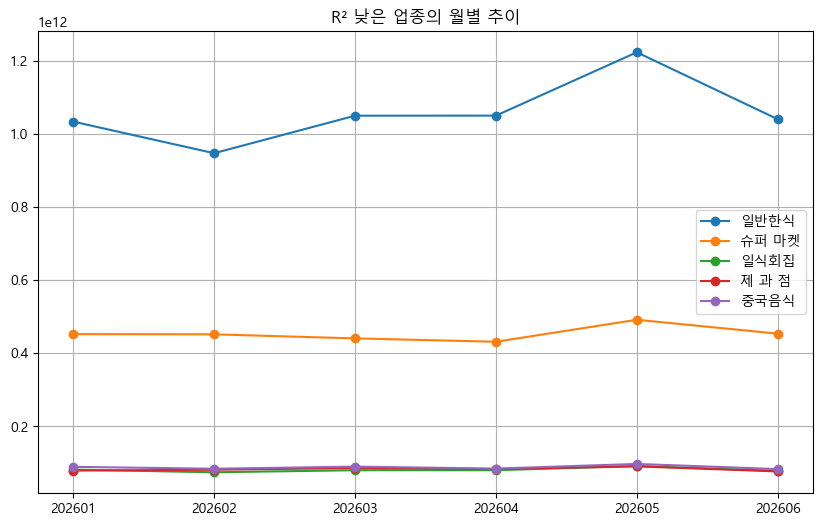

In [32]:
# R²가 낮았던 업종만 따로 뽑아서 다시 확인
low_r2_industries = ['일반한식', '슈퍼 마켓', '일식회집', '제 과 점', '중국음식']

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
for industry in low_r2_industries:
    plt.plot(
        industry_pivot.index.astype(str),
        industry_pivot[industry],
        marker='o',
        label=industry
    )
plt.title('R² 낮은 업종의 월별 추이')
plt.legend()
plt.grid()
plt.show()